# 트리 기반 모델 - 타이타닉 생존 여부 예측
## Decision Tree / Random Forest / Gradient Boosting

In [12]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

## 1. 데이터 로드 및 전처리

In [13]:
# 데이터 로드
df = pd.read_csv(r'pandas/data/titanic_train.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town
0,0,3,male,22.0,1,0,7.2500,Southampton
1,1,1,female,38.0,1,0,71.2833,Cherbourg
2,1,3,female,26.0,0,0,7.9250,Southampton
3,1,1,female,35.0,1,0,53.1000,Southampton
4,0,3,male,35.0,0,0,8.0500,Southampton


In [14]:
# 결측치 처리
# age: 중앙값으로 대치 (177개 결측)
df['age'] = df['age'].fillna(df['age'].median())

# embark_town: 최빈값으로 대치 (2개 결측)
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# 범주형 변수 원핫인코딩
df = pd.get_dummies(df, columns=['sex', 'embark_town'], drop_first=True, dtype='i1')

print('전처리 완료')
df.head()

전처리 완료


,survived,pclass,age,sibsp,parch,fare,sex_male,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [15]:
from sklearn.model_selection import train_test_split

# 독립변수(X)와 종속변수(y) 분리
X = df.drop(columns=['survived'])
y = df['survived']

# 학습/테스트 분리 (8:2)
# 트리 기반 모델은 스케일링이 필요 없으므로 원본 그대로 사용
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (712, 8), Test: (179, 8)


In [16]:
# 평가 함수 정의
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(name, y_true, y_pred):
    """모델 평가 결과를 출력하고 딕셔너리로 반환"""
    acc = accuracy_score(y_true, y_pred)
    print(f'=== {name} ===')
    print(f'Accuracy: {acc:.4f}\n')
    print(classification_report(y_true, y_pred, target_names=['사망(0)', '생존(1)']))
    return {'model': name, 'accuracy': acc}

## 2. Decision Tree (의사결정나무)

In [17]:
from sklearn.tree import DecisionTreeClassifier

# 모델 생성 및 학습
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# 예측 및 평가
y_pred_dt = dt.predict(X_test)
results = []
results.append(evaluate_model('Decision Tree', y_test, y_pred_dt))

=== Decision Tree ===
Accuracy: 0.7821

              precision    recall  f1-score   support

       사망(0)       0.82      0.80      0.81       105
       생존(1)       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



## 3. Random Forest (랜덤 포레스트)

In [18]:
from sklearn.ensemble import RandomForestClassifier

# 모델 생성 및 학습 (100개의 트리로 구성)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 예측 및 평가
y_pred_rf = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.8212

              precision    recall  f1-score   support

       사망(0)       0.83      0.87      0.85       105
       생존(1)       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## 4. Gradient Boosting (그라디언트 부스팅)

In [19]:
from sklearn.ensemble import GradientBoostingClassifier

# 모델 생성 및 학습 (100개의 트리를 순차적으로 학습)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

# 예측 및 평가
y_pred_gb = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred_gb))

=== Gradient Boosting ===
Accuracy: 0.8045

              precision    recall  f1-score   support

       사망(0)       0.80      0.90      0.84       105
       생존(1)       0.82      0.68      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.80      0.80       179



## 5. 모델 성능 비교

In [20]:
# 모델별 정확도 비교 표
result_df = pd.DataFrame(results)
result_df = result_df.sort_values('accuracy', ascending=False).reset_index(drop=True)
result_df

,model,accuracy
0,Random Forest,0.821229
1,Gradient Boosting,0.804469
2,Decision Tree,0.782123


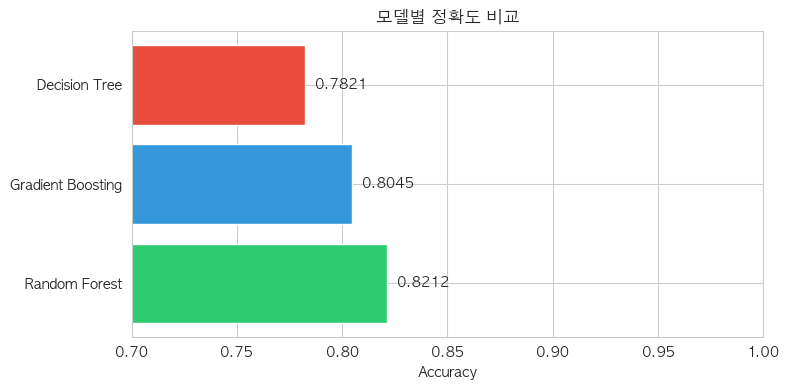

In [21]:
# 모델별 정확도 시각화
plt.figure(figsize=(8, 4))
colors = ['#2ecc71', '#3498db', '#e74c3c']
plt.barh(result_df['model'], result_df['accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('모델별 정확도 비교')
plt.xlim(0.7, 1.0)

# 막대 위에 수치 표시
for i, v in enumerate(result_df['accuracy']):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

## 6. 변수 중요도 비교

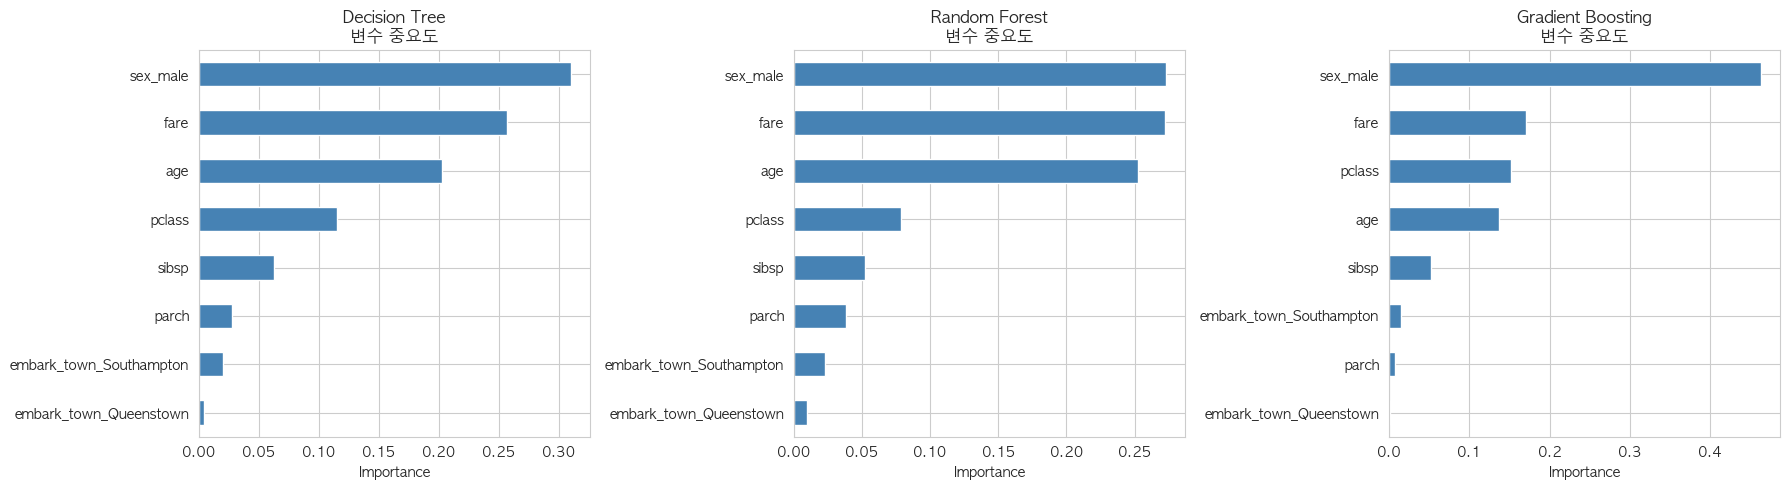

In [22]:
# 세 모델의 feature_importances_ 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model, name in zip(axes, [dt, rf, gb], ['Decision Tree', 'Random Forest', 'Gradient Boosting']):
    # 변수 중요도를 정렬
    importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values()
    importance.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name}\n변수 중요도')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 7. 성능 개선 - 하이퍼파라미터 튜닝

In [23]:
from sklearn.model_selection import GridSearchCV

# Decision Tree 하이퍼파라미터 튜닝
dt_params = {
    'max_depth': [3, 5, 7, 10, None],          # 트리 최대 깊이
    'min_samples_split': [2, 5, 10],            # 분할에 필요한 최소 샘플 수
    'min_samples_leaf': [1, 2, 5],              # 리프 노드 최소 샘플 수
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=5, scoring='accuracy', n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print(f'최적 파라미터: {dt_grid.best_params_}')
print(f'최적 CV 점수: {dt_grid.best_score_:.4f}')

# 최적 모델로 테스트 평가
y_pred_dt2 = dt_grid.predict(X_test)
results_tuned = []
results_tuned.append(evaluate_model('Decision Tree (튜닝)', y_test, y_pred_dt2))

최적 파라미터: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
최적 CV 점수: 0.8244
=== Decision Tree (튜닝) ===
Accuracy: 0.7989

              precision    recall  f1-score   support

       사망(0)       0.80      0.88      0.84       105
       생존(1)       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [24]:
# Random Forest 하이퍼파라미터 튜닝
rf_params = {
    'n_estimators': [100, 200, 300],            # 트리 개수
    'max_depth': [5, 10, 15, None],             # 트리 최대 깊이
    'min_samples_split': [2, 5, 10],            # 분할에 필요한 최소 샘플 수
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f'최적 파라미터: {rf_grid.best_params_}')
print(f'최적 CV 점수: {rf_grid.best_score_:.4f}')

# 최적 모델로 테스트 평가
y_pred_rf2 = rf_grid.predict(X_test)
results_tuned.append(evaluate_model('Random Forest (튜닝)', y_test, y_pred_rf2))

최적 파라미터: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
최적 CV 점수: 0.8356
=== Random Forest (튜닝) ===
Accuracy: 0.8156

              precision    recall  f1-score   support

       사망(0)       0.81      0.90      0.85       105
       생존(1)       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



In [25]:
# Gradient Boosting 하이퍼파라미터 튜닝
gb_params = {
    'n_estimators': [100, 200, 300],            # 트리 개수
    'learning_rate': [0.05, 0.1, 0.2],          # 학습률 (작을수록 신중하게 학습)
    'max_depth': [3, 5, 7],                     # 트리 최대 깊이
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=5, scoring='accuracy', n_jobs=-1
)
gb_grid.fit(X_train, y_train)

print(f'최적 파라미터: {gb_grid.best_params_}')
print(f'최적 CV 점수: {gb_grid.best_score_:.4f}')

# 최적 모델로 테스트 평가
y_pred_gb2 = gb_grid.predict(X_test)
results_tuned.append(evaluate_model('Gradient Boosting (튜닝)', y_test, y_pred_gb2))

최적 파라미터: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
최적 CV 점수: 0.8230
=== Gradient Boosting (튜닝) ===
Accuracy: 0.8212

              precision    recall  f1-score   support

       사망(0)       0.83      0.88      0.85       105
       생존(1)       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## 8. 튜닝 전후 성능 비교

In [26]:
# 기본 모델 vs 튜닝 모델 비교 표
all_results = results + results_tuned
all_df = pd.DataFrame(all_results).sort_values('accuracy', ascending=False).reset_index(drop=True)
all_df

,model,accuracy
0,Random Forest,0.821229
1,Gradient Boosting (튜닝),0.821229
2,Random Forest (튜닝),0.815642
3,Gradient Boosting,0.804469
4,Decision Tree (튜닝),0.798883
5,Decision Tree,0.782123


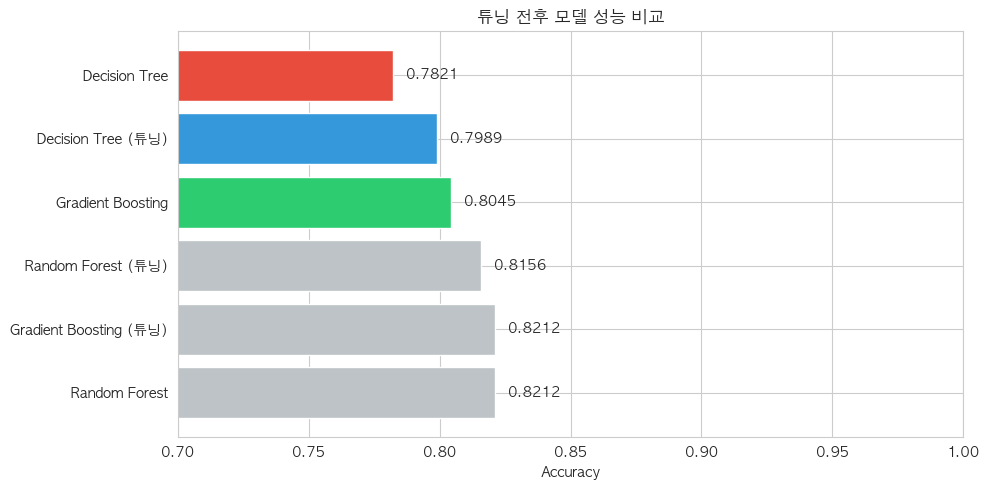

In [27]:
# 튜닝 전후 비교 시각화
plt.figure(figsize=(10, 5))
colors = ['#bdc3c7', '#bdc3c7', '#bdc3c7', '#2ecc71', '#3498db', '#e74c3c']
plt.barh(all_df['model'], all_df['accuracy'], color=colors[:len(all_df)])
plt.xlabel('Accuracy')
plt.title('튜닝 전후 모델 성능 비교')
plt.xlim(0.7, 1.0)

# 막대 위에 수치 표시
for i, v in enumerate(all_df['accuracy']):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()